# EDA - 1 Title: Bike Details Dataset

In [102]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
df = pd.read_csv("/content/BIKE DETAILS.csv")

In [104]:
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


In [106]:
df.describe()

,selling_price,year,km_driven,ex_showroom_price
count,1061.000000,1061.000000,1061.000000,6.260000e+02
mean,59638.151744,2013.867107,34359.833176,8.795871e+04
std,56304.291973,4.301191,51623.152702,7.749659e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [107]:
# Q1 What is the range of selling prices in the datasetD
min_price = df['selling_price'].min()
max_price = df['selling_price'].max()

print("Minimum price:", min_price)
print("Maximum price:", max_price)
print("Range:", max_price - min_price)

Minimum price: 5000
Maximum price: 760000
Range: 755000


In [108]:
# Q2 What is the median selling price for bikes in the datasetD
median_price = df['selling_price'].median()
print("Median selling price:", median_price)

Median selling price: 45000.0


In [109]:
# Q3 What is the most common seller type?
most_common_seller = df['seller_type'].mode()[0]
print("Most common seller type:", most_common_seller)

Most common seller type: Individual


In [110]:
# Q4 How many bikes have driven more than 50,000 kilometers?
bikes_above_50k = df[df['km_driven'] > 50000]
print("Number of bikes driven more than 50,000 km:", len(bikes_above_50k))

Number of bikes driven more than 50,000 km: 170


In [111]:
# Q5 What is the average km_driven value for each ownership type?
avg_km_owner = df.groupby('owner')['km_driven'].mean()
print(avg_km_owner)


owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64


In [112]:
# Q6  What proportion of bikes are from the year 2015 or older?
total_bikes = len(df)
older_bikes = len(df[df['year'] <= 2015])

proportion = older_bikes / total_bikes
print("Proportion of bikes from 2015 or older:", proportion)

Proportion of bikes from 2015 or older: 0.5664467483506126


In [113]:
# Q7 What is the trend of missing values across the dataset?
missing_values = df.isnull().sum()
print(missing_values)

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


In [114]:
# Q8 What is the highest ex_showroom_price recorded, and for which bike?
max_ex_price = df['ex_showroom_price'].max()

bike_highest_price = df[df['ex_showroom_price'] == max_ex_price]

print("Highest ex_showroom_price:", max_ex_price)
print(bike_highest_price[['name','ex_showroom_price']])

Highest ex_showroom_price: 1278000.0
                           name  ex_showroom_price
134  Harley-Davidson Street Bob          1278000.0


In [115]:
# Q9 What is the total number of bikes listed by each seller type?
seller_counts = df['seller_type'].value_counts()
print(seller_counts)

seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64


Correlation between selling_price and km_driven: -0.2434817484496572


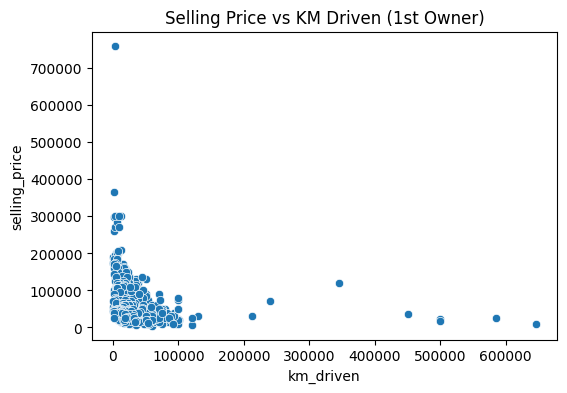

In [116]:
# Q10  What is the relationship between selling_price and km_driven for first-owner bikes?
first_owner = df[df['owner'] == '1st owner']

correlation = first_owner['selling_price'].corr(first_owner['km_driven'])

print("Correlation between selling_price and km_driven:", correlation)

# Scatterplot
plt.figure(figsize=(6,4))
sns.scatterplot(x='km_driven', y='selling_price', data=first_owner)
plt.title("Selling Price vs KM Driven (1st Owner)")
plt.show()

In [117]:
# Q11  Identify and remove outliers in the km_driven column using the IQR method?
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['km_driven'] < lower) | (df['km_driven'] > upper)]

print("Number of outliers:", len(outliers))

# Remove outliers
df_clean = df[(df['km_driven'] >= lower) & (df['km_driven'] <= upper)]

Number of outliers: 39


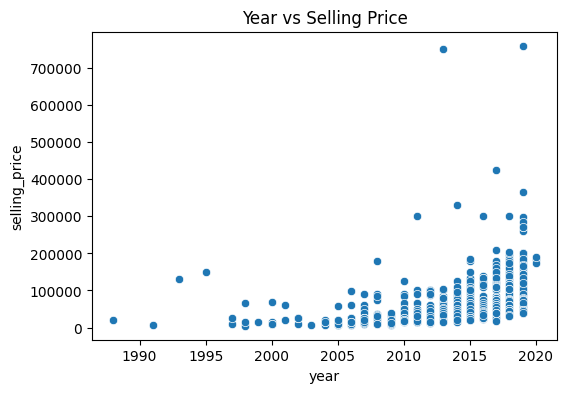

Correlation: 0.40218840061474403


In [118]:
# Q12  Perform a bivariate analysis to visualize the relationship between year and selling_price?
plt.figure(figsize=(6,4))
sns.scatterplot(x='year', y='selling_price', data=df)
plt.title("Year vs Selling Price")
plt.show()

# correlation
corr_year_price = df['year'].corr(df['selling_price'])
print("Correlation:", corr_year_price)

In [119]:
# Q13 What is the average depreciation in selling price based on the bike's age (current year - manufacturing year?
current_year = 2025

df['bike_age'] = current_year - df['year']

df['depreciation'] = df['ex_showroom_price'] - df['selling_price']

avg_depreciation = df.groupby('bike_age')['depreciation'].mean()

print(avg_depreciation)


bike_age
5    -34260.000000
6      2954.562500
7     13023.194805
8     22306.082353
9     28328.190476
10    28013.275000
11    34505.606061
12    43086.886792
13    37317.648649
14    47102.666667
15    45658.928571
16    38227.785714
17    54732.428571
18    42399.000000
19    39664.500000
20    44852.000000
21    36852.000000
22             NaN
23             NaN
24    34852.000000
25             NaN
26             NaN
27             NaN
28             NaN
30             NaN
32             NaN
34             NaN
37             NaN
Name: depreciation, dtype: float64


In [120]:
# Q14 Which bike names are priced significantly above the average price for their manufacturing year?
year_avg = df.groupby('year')['selling_price'].mean()

df = df.merge(year_avg, on='year', suffixes=('','_year_avg'))

above_avg_bikes = df[df['selling_price'] > df['selling_price_year_avg']]

print(above_avg_bikes[['name','year','selling_price']])

                                      name  year  selling_price
0                Royal Enfield Classic 350  2019         175000
2      Royal Enfield Classic Gunmetal Grey  2018         150000
3        Yamaha Fazer FI V 2.0 [2016-2018]  2015          65000
7     Royal Enfield Bullet 350 [2007-2011]  2008         180000
13                           Yamaha YZF R3  2019         365000
...                                    ...   ...            ...
1004                  Bajaj Pulsar  NS 200  2016          60000
1005                    TVS Apache RTR 160  2014          60000
1008                    Bajaj Pulsar 220 F  2012          52000
1012                   Bajaj Pulsar NS 200  2014          50000
1023                Bajaj Avenger 220 dtsi  2012          45000

[334 rows x 3 columns]


                   selling_price      year  km_driven  ex_showroom_price
selling_price           1.000000  0.402188  -0.212937           0.918583
year                    0.402188  1.000000  -0.288675           0.126378
km_driven              -0.212937 -0.288675   1.000000          -0.122011
ex_showroom_price       0.918583  0.126378  -0.122011           1.000000


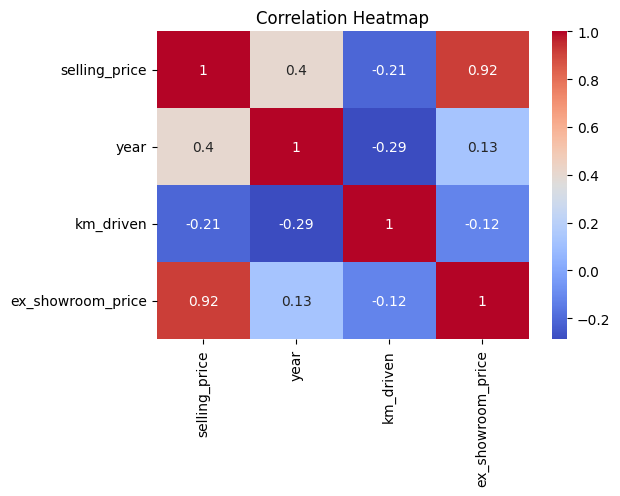

In [121]:
# Q15  Develop a correlation matrix for numeric columns and visualize it using a heatmap.
numeric_cols = df[['selling_price','year','km_driven','ex_showroom_price']]

corr_matrix = numeric_cols.corr()

print(corr_matrix)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# EDA :- 2 Title: Car Sale Dataset

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
df = pd.read_csv("/content/Car Sale.csv")

In [124]:
df


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [126]:
df.describe()

,Annual Income,Price ($),Phone
count,2.390600e+04,23906.000000,2.390600e+04
mean,8.308403e+05,28090.247846,7.497741e+06
std,7.200064e+05,14788.687608,8.674920e+05
min,1.008000e+04,1200.000000,6.000101e+06
25%,3.860000e+05,18001.000000,6.746495e+06
50%,7.350000e+05,23000.000000,7.496198e+06
75%,1.175750e+06,34000.000000,8.248146e+06
max,1.120000e+07,85800.000000,8.999579e+06


Dealer_Name
U-Haul CO                                          28769.919006
Classic Chevy                                      28602.014446
Rabun Used Car Sales                               28527.536177
Iceberg Rentals                                    28522.958533
Enterprise Rent A Car                              28312.580800
Scrivener Performance Engineering                  28297.371589
Gartner Buick Hyundai Saab                         28247.621019
Saab-Belle Dodge                                   28190.139888
Capitol KIA                                        28189.703822
Race Car Help                                      28163.372706
Chrysler of Tri-Cities                             28123.091054
Star Enterprises Inc                               28113.055244
Suburban Ford                                      28112.206758
C & M Motors Inc                                   28111.755200
Tri-State Mack Inc                                 28095.562050
Pars Auto Sales             

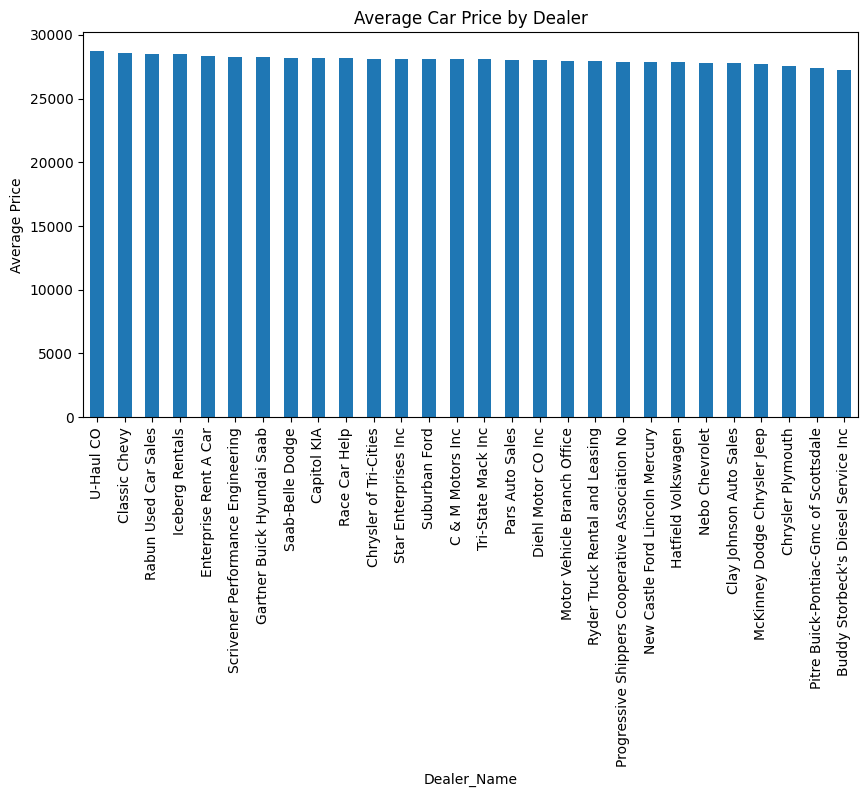

In [127]:
# Q1 What is the average selling price of cars for each dealer, and how does it compare across different dealers?

dealer_avg_price = df.groupby('Dealer_Name')['Price ($)'].mean().sort_values(ascending=False)

print(dealer_avg_price)

# Visualization
plt.figure(figsize=(10,5))
dealer_avg_price.plot(kind='bar')
plt.title("Average Car Price by Dealer")
plt.ylabel("Average Price")
plt.show()

In [128]:
# Q2 Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

brand_variation = df.groupby('Company')['Price ($)'].std().sort_values(ascending=False)

print(brand_variation)

# Highest variation
print("Brand with highest variation:", brand_variation.idxmax())

Company
Lincoln       19658.050211
Saab          19653.740089
Cadillac      19517.120220
Plymouth      19065.997338
Lexus         17852.923492
Buick         17142.232626
Mercury       16445.172195
Nissan        16214.264017
Saturn        15990.223671
Ford          15849.090227
Mercedes-B    15722.807459
Oldsmobile    15711.345857
Toyota        15367.131714
BMW           15065.578723
Pontiac       14348.963592
Infiniti      13696.332844
Chevrolet     13311.063223
Volvo         12933.790185
Subaru        12920.771620
Audi          12904.243867
Volkswagen    12527.124011
Mitsubishi    11671.343035
Chrysler      11583.286811
Dodge         11187.592085
Honda         11148.629062
Jaguar        10222.531533
Jeep           9459.834418
Acura          8183.046414
Porsche        5261.839206
Hyundai        3485.982649
Name: Price ($), dtype: float64
Brand with highest variation: Lincoln


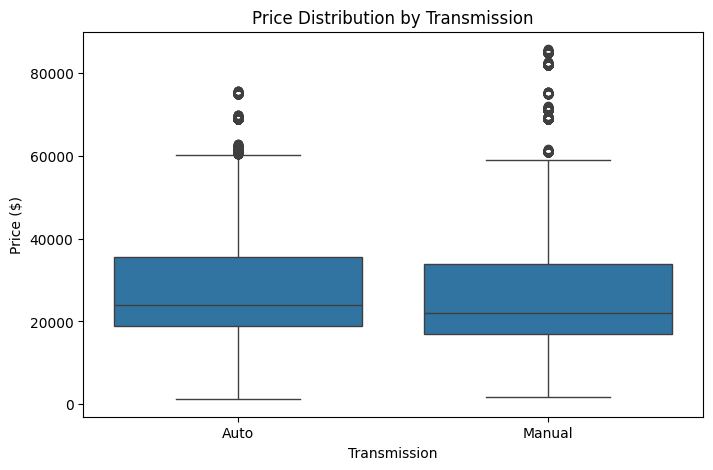

In [129]:
# Q3  What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?
plt.figure(figsize=(8,5))
sns.boxplot(x='Transmission', y='Price ($)', data=df)
plt.title("Price Distribution by Transmission")
plt.show()

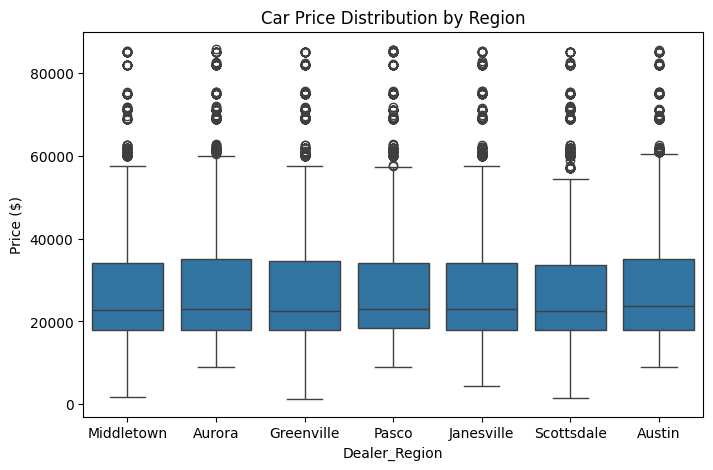

In [130]:
# Q4 What is the distribution of car prices across different regionse?
plt.figure(figsize=(8,5))
sns.boxplot(x='Dealer_Region', y='Price ($)', data=df)
plt.title("Car Price Distribution by Region")
plt.show()

Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64


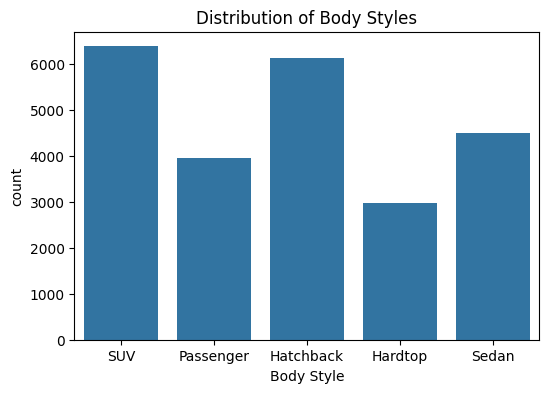

In [131]:
# Q5  What is the distribution of cars based on body stylesE
body_style_count = df['Body Style'].value_counts()

print(body_style_count)

plt.figure(figsize=(6,4))
sns.countplot(x='Body Style', data=df)
plt.title("Distribution of Body Styles")
plt.show()

In [132]:
# Q6 How does the average selling price of cars vary by customer gender and annual income?
gender_income_price = df.groupby(['Gender','Annual Income'])['Price ($)'].mean()

print(gender_income_price)

Gender  Annual Income
Female  13500            28132.038732
        106000           46001.000000
        121000           20000.000000
        190000           19001.000000
        211000           51000.000000
                             ...     
Male    6600000          39000.000000
        6800000          15000.000000
        7650000          21000.000000
        8000000          85000.000000
        11200000         26001.000000
Name: Price ($), Length: 3442, dtype: float64


               total_sales     avg_price
Dealer_Region                           
Aurora                3130  28334.626837
Austin                4135  28341.603628
Greenville            3128  28180.819054
Janesville            3821  27833.350955
Middletown            3128  27856.338875
Pasco                 3131  28119.039923
Scottsdale            3433  27954.958928


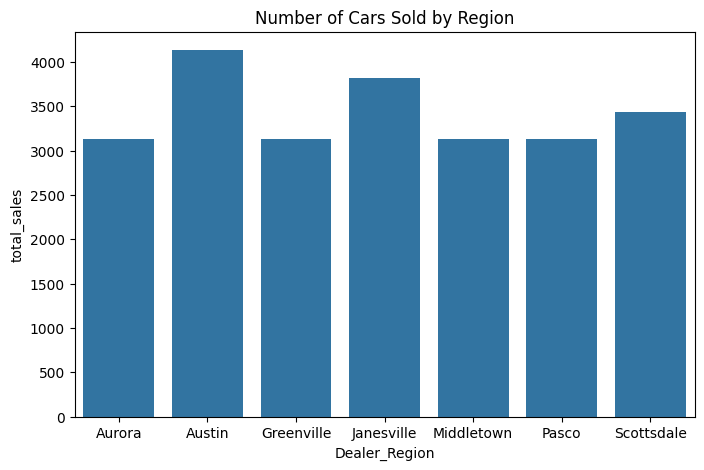

In [133]:
# Q7  What is the distribution of car prices by region, and how does the number of cars sold vary by region?
region_sales = df.groupby('Dealer_Region').agg(
    total_sales=('Price ($)','count'),
    avg_price=('Price ($)','mean')
)

print(region_sales)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales['total_sales'])
plt.title("Number of Cars Sold by Region")
plt.show()

In [135]:
# Q8 How does the average car price differ between cars with different engine sizesE
import matplotlib.pyplot as plt

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Group by engine size
engine_price = df.groupby('Engine_Size')['Price ($)'].mean()

print(engine_price)

# Plot
plt.figure(figsize=(6,4))
engine_price.plot(kind='bar')
plt.title("Average Price by Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Average Price ($)")
plt.show()

KeyError: 'Engine_Size'

In [ ]:
# Q9  How do car prices vary based on the customer’s annual income bracket?
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income', y='Price ($)', data=df)
plt.title("Car Price vs Customer Income")
plt.show()

In [ ]:
# Q10  What are the top 5 car models with the highest number of sales, and how does their price distribution look?
top_models = df['Model'].value_counts().head(5)

print(top_models)

top_model_names = top_models.index

top_model_data = df[df['Model'].isin(top_model_names)]

plt.figure(figsize=(8,5))
sns.boxplot(x='Model', y='Price ($)', data=top_model_data)
plt.title("Price Distribution of Top 5 Models")
plt.show()

In [ ]:
# Q11  How does car price vary with engine size across different car colors, and which colors have the highest price variation?
plt.figure(figsize=(8,5))
sns.scatterplot(x='Engine Size', y='Price ($)', hue='Color', data=df)
plt.title("Engine Size vs Price by Color")
plt.show()

# Color price variation
color_variation = df.groupby('Color')['Price ($)'].std()

print(color_variation.sort_values(ascending=False))

In [ ]:
# Q12  Is there any seasonal trend in car sales based on the date of sale?
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Price ($)'].count()

print(monthly_sales)

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Car Sales Trend")
plt.xlabel("Month")
plt.ylabel("Number of Sales")
plt.show()

In [ ]:
# Q13  How does the car price distribution change when considering different combinations of body style and transmission type?
plt.figure(figsize=(10,6))
sns.boxplot(x='Body Style', y='Price ($)', hue='Transmission', data=df)
plt.title("Price Distribution by Body Style and Transmission")
plt.show()

In [ ]:
# Q14 What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?
corr_data = df[['Price ($)','Engine Size','Annual Income']]

corr_matrix = corr_data.corr()

print(corr_matrix)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Q15  How does the average car price vary across different car models and engine types?
model_engine_price = df.groupby(['Model','Engine Size'])['Price ($)'].mean()

print(model_engine_price)

# Pivot table
pivot_table = df.pivot_table(values='Price ($)', index='Model', columns='Engine Size', aggfunc='mean')

print(pivot_table)

# EDA - 3 Amazon Sales Data

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [137]:
df = pd.read_csv("amazon.csv")

In [138]:
df

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,₹379,₹919,59%,4,"1,090",SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,280","₹3,045",25%,4.1,"4,118","230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the me

In [139]:
print(df.head())

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

In [140]:
print(df.columns)

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')


In [141]:
df.columns = df.columns.str.strip()

In [142]:
# Q1 What is the average rating for each product category?
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("amazon.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert rating column to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Remove rows with missing ratings
df = df.dropna(subset=['rating'])

# Calculate average rating for each category
avg_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)

print(avg_rating)



category
Computers&Accessories|Tablets                                                                                    4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters                                         4.5
Electronics|Cameras&Photography|Accessories|Film                                                                 4.5
Computers&Accessories|Components|Memory                                                                          4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                                                     4.5
                                                                                                                ... 
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                               3.6
Electronics|HomeTheater,TV&Video|Accessories|3DGlasses                                                           3.5
Computers&Accessories|Accessories&Peripherals|Audio&Vid

In [143]:
# Q2  What are the top rating_count products by category?
top_products = df.sort_values('rating_count', ascending=False)

top_products_by_category = top_products.groupby('category').head(5)

print(top_products_by_category[['product_name','category','rating_count']])

                                           product_name  \
750        Eveready Red 1012 AAA Batteries - Pack of 10   
977   Sennheiser CX 80S in-Ear Wired Headphones with...   
1059  Pigeon 1.5 litre Hot Kettle and Stainless Stee...   
32    Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...   
151   Zoul USB Type C Fast Charging 3A Nylon Braided...   
...                                                 ...   
1172  Eureka Forbes Supervac 1600 Watts Powerful Suc...   
1157  Reffair AX30 [MAX] Portable Air Purifier for C...   
1191  Akiara® - Makes life easy Mini Sewing Machine ...   
1399  Cafe JEI French Press Coffee and Tea Maker 600...   
1104  AGARO Supreme High Pressure Washer, 1800 Watts...   

                                               category rating_count  
750   Electronics|GeneralPurposeBatteries&BatteryCha...          989  
977   Electronics|Headphones,Earbuds&Accessories|Hea...       98,250  
1059  Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...          976  
32    C

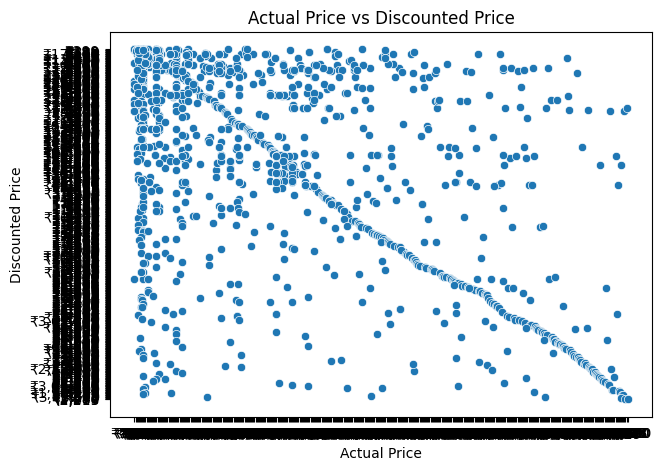

In [144]:
# Q3  What is the distribution of discounted prices vs. actual prices?

plt.figure(figsize=(7,5))
sns.scatterplot(x='actual_price', y='discounted_price', data=df)

plt.title("Actual Price vs Discounted Price")
plt.xlabel("Actual Price")
plt.ylabel("Discounted Price")
plt.show()

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors                            90.0
Electronics|Headphones,Earbuds&Accessories|Earpads                                                                    90.0
Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms                                                   90.0
Electronics|Headphones,Earbuds&Accessories|Adapters                                                                   88.0
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers         87.5
                                                                                                                      ... 
OfficeProducts|OfficeElectronics|Calculators|Financial&Business                                                        0.0
OfficeProducts|OfficePaperProducts|Paper|Copy&PrintingPaper|ColouredPaper                                              0.0
OfficeP

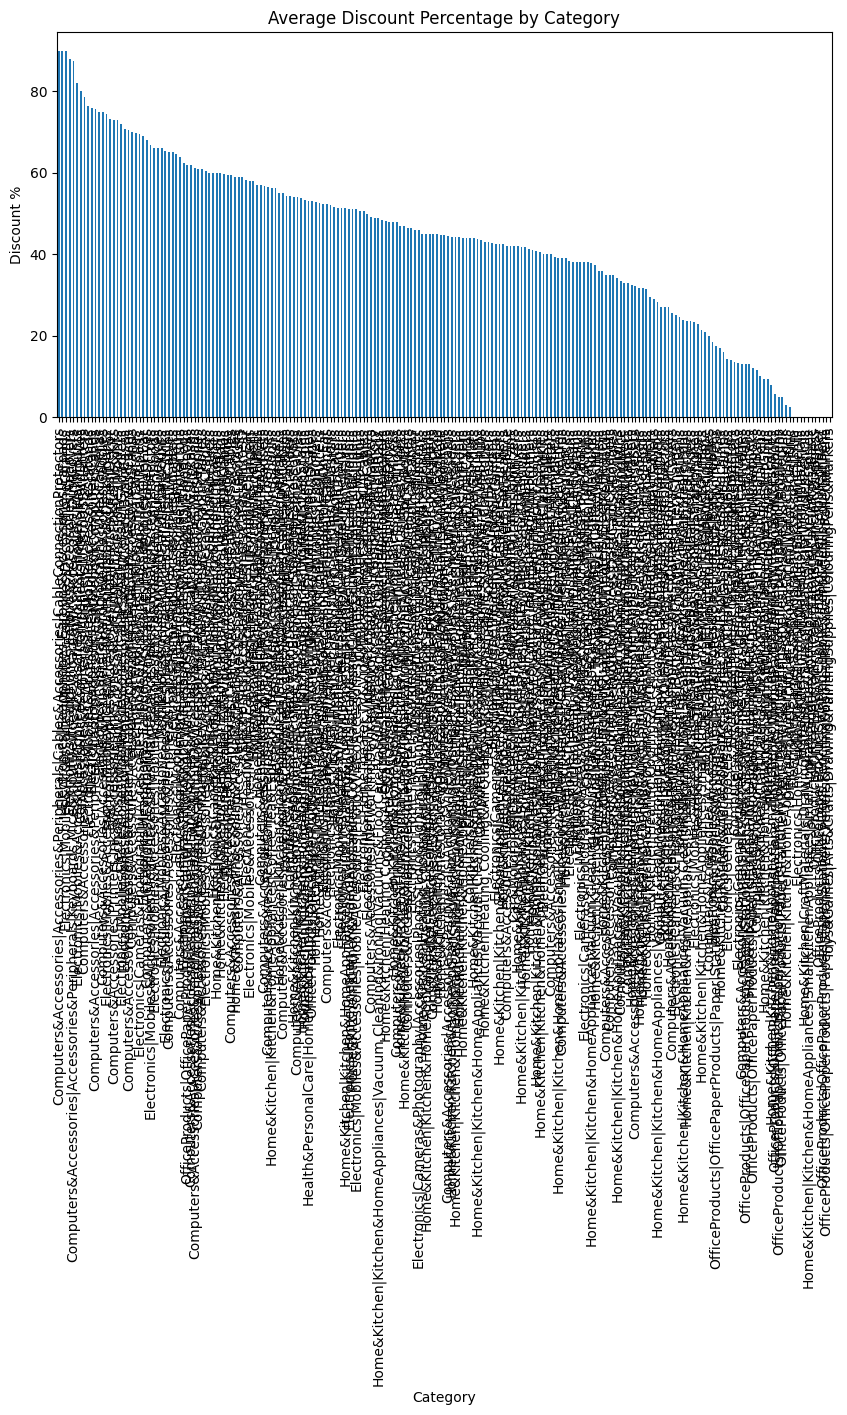

In [145]:
# Q4 How does the average discount percentage vary across categories?
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("amazon.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert discount percentage to numeric
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').astype(float)

# Average discount by category
avg_discount = df.groupby('category')['discount_percentage'].mean().sort_values(ascending=False)

print(avg_discount)

# Plot
plt.figure(figsize=(10,5))
avg_discount.plot(kind='bar')

plt.title("Average Discount Percentage by Category")
plt.xlabel("Category")
plt.ylabel("Discount %")

plt.xticks(rotation=90)
plt.show()




In [146]:
# Q5 What are the most popular product names?
popular_products = df['product_name'].value_counts().head(10)

print(popular_products)



product_name
Fire-Boltt Ninja Call Pro Plus 1.83" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution                                                  5
Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating                                                           4
Amazonbasics Nylon Braided Usb-C To Lightning Cable, Fast Charging Mfi Certified Smartphone, Iphone Charger (6-Foot, Dark Grey)                                                                            3
Duracell USB Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black                                                 3
Flix Micro Usb Cable For Smartphone (Black)                                                                                                                            

product_name
with        718
for         614
|           457
&           432
USB         342
and         310
Cable       306
-           220
Charging    212
Fast        208
to          202
(Black)     184
C           176
Smart       171
Type        140
Name: count, dtype: int64


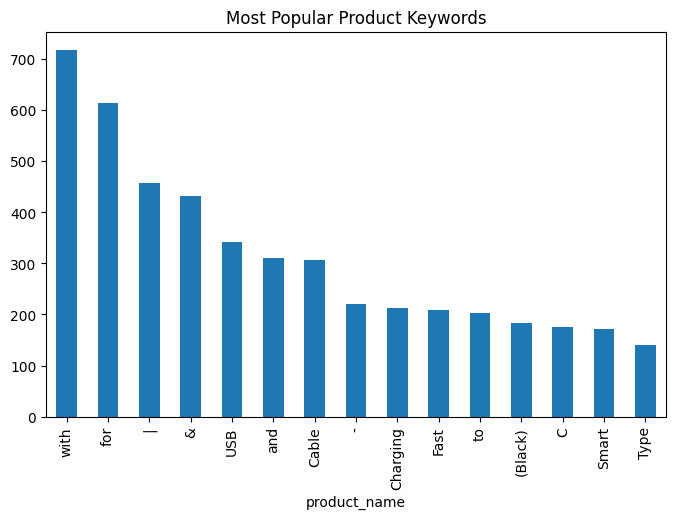

In [147]:
# Q6 What are the most popular product keywords?
# Extract keywords from product names
keywords = df['product_name'].str.split().explode()

top_keywords = keywords.value_counts().head(15)

print(top_keywords)

plt.figure(figsize=(8,5))
top_keywords.plot(kind='bar')
plt.title("Most Popular Product Keywords")
plt.show()

In [148]:
# Q7 What are the most popular product reviews?
popular_reviews = df.sort_values('rating_count', ascending=False)[['product_name','review_content','rating_count']].head(10)

print(popular_reviews)

                                           product_name  \
1279  Eureka Forbes car Vac 100 Watts Powerful Sucti...   
750        Eveready Red 1012 AAA Batteries - Pack of 10   
977   Sennheiser CX 80S in-Ear Wired Headphones with...   
1059  Pigeon 1.5 litre Hot Kettle and Stainless Stee...   
151   Zoul USB Type C Fast Charging 3A Nylon Braided...   
32    Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...   
823   Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...   
536   boAt Rockerz 400 Bluetooth On Ear Headphones W...   
918   boAt Rockerz 400 Bluetooth On Ear Headphones W...   
1165  Kitchenwell 18Pc Plastic Food Snack Bag Pouch ...   

                                         review_content rating_count  
1279  Does the job well,doesn't work on sand. though...          992  
750   Nive,very good batteries received,Like,Good pr...          989  
977   For those looking for a genuine review & a bri...       98,250  
1059  Bottle quality is not good.,Best for hot water...          9

In [149]:
# Q8 What is the correlation between discounted_price and rating?
corr = df[['discounted_price','rating']].corr()

print(corr)

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Discounted Price and Rating")
plt.show()

ValueError: could not convert string to float: '₹399'

In [150]:
# Q9 What are the Top 5 categories based on the highest ratings?
top_categories  =  df.groupby('category')['rating'].mean().sort_values(ascending=False).head(5)

print(top_categories)




TypeError: agg function failed [how->mean,dtype->object]

In [151]:
# Q10  Identify any potential areas for improvement or optimization based on the data analysis.
low_rating_products = df[df['rating'] < 3]

print(low_rating_products[['product_name','category','rating']].head(10))

# Count of low-rated categories
low_rating_categories = low_rating_products['category'].value_counts()

print(low_rating_categories)

TypeError: '<' not supported between instances of 'str' and 'int'

# EDA - 4

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [153]:
# Load dataset
df = pd.read_csv("spotify.csv")

In [160]:
# Q1 Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful

# Display first rows
print(df.head())

  Artist                               Track Name  Popularity  Duration (ms)  \
0  Drake  Rich Baby Daddy (feat. Sexyy Red & SZA)          92         319191   
1  Drake                                One Dance          91         173986   
2  Drake                       IDGAF (feat. Yeat)          90         260111   
3  Drake     First Person Shooter (feat. J. Cole)          88         247444   
4  Drake            Jimmy Cooks (feat. 21 Savage)          88         218364   

                 Track ID  
0  1yeB8MUNeLo9Ek1UEpsyz6  
1  1zi7xx7UVEFkmKfv06H8x0  
2  2YSzYUF3jWqb9YP9VXmpjE  
3  7aqfrAY2p9BUSiupwk3svU  
4  3F5CgOj3wFlRv51JsHbxhe  


In [155]:
# Check null values
print("Null values:\n", df.isnull().sum())

Null values:
 Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64


In [156]:
# Handle null values
df = df.dropna()


In [157]:

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 27


In [158]:
# Remove duplicates
df = df.drop_duplicates()

In [159]:
print("Data cleaned successfully")

Data cleaned successfully


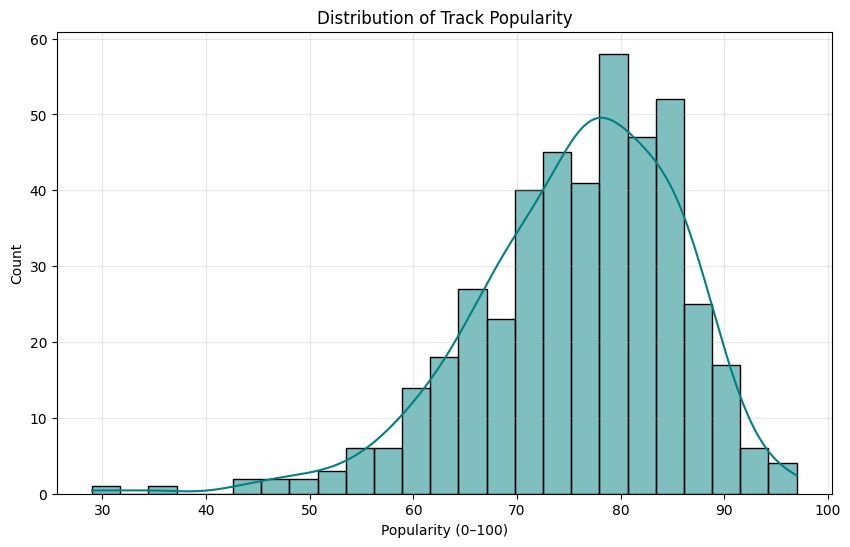

Popularity stats:
count    440.000000
mean      75.736364
std        9.886534
min       29.000000
25%       70.000000
50%       77.000000
75%       83.000000
max       97.000000
Name: Popularity, dtype: float64


In [165]:
# Q2 What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram?
#  2. Distribution of Popularity – Histogram
# ───────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.histplot(df['Popularity'], bins=25, kde=True, color='teal')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity (0–100)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

print("Popularity stats:")
print(df['Popularity'].describe())

In [168]:
# Q3 Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot?

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration_min', y='Popularity', alpha=0.6, color='purple')
plt.title('Popularity vs Track Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity')
plt.grid(True, alpha=0.3)
plt.show()

print("Correlation between Popularity and Duration:",
      df['Popularity'].corr(df['Duration (ms)']).round(4))

ValueError: Could not interpret value `Duration_min` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

/tmp/ipykernel_339/1978231535.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Artist'], order=top_artists.index, palette='viridis')


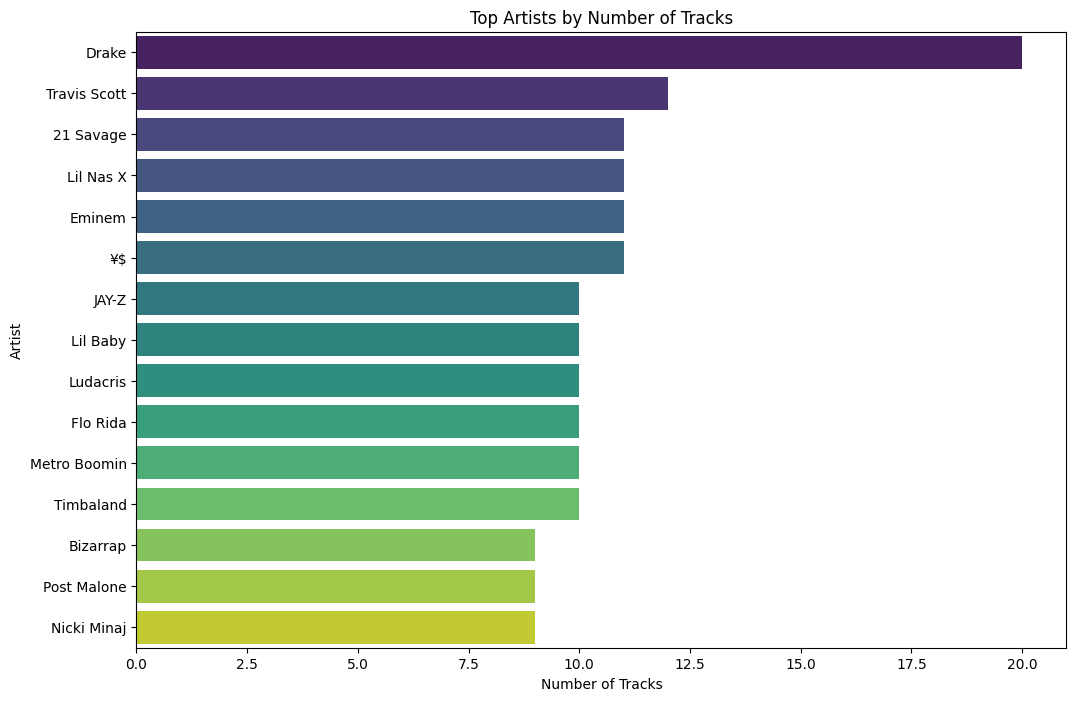

Artist with most tracks:
 Artist
Drake    20
Name: count, dtype: int64


In [169]:
# Q4  Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot?

plt.figure(figsize=(12, 8))
top_artists = df['Artist'].value_counts().head(15)
sns.countplot(y=df['Artist'], order=top_artists.index, palette='viridis')
plt.title('Top Artists by Number of Tracks')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.show()

print("Artist with most tracks:\n", top_artists.head(1))

In [170]:
# Q5 What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each?
least_popular = df.sort_values('Popularity').head(5)[['Artist', 'Track Name', 'Popularity']]
print("\nTop 5 least popular tracks:")
print(least_popular.to_string(index=False))


Top 5 least popular tracks:
        Artist                    Track Name  Popularity
        Pressa Attachments (feat. Coi Leray)          29
 Justin Bieber                    Intentions          35
French Montana               Splash Brothers          44
French Montana               Splash Brothers          44
      Lil Baby                 On Me - Remix          47


In [171]:
# Q6 Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist ?
top5_artists = df['Artist'].value_counts().head(5).index

avg_pop_by_artist = (
    df[df['Artist'].isin(top5_artists)]
    .groupby('Artist')['Popularity']
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

print("\nAverage popularity for top 5 most frequent artists:")
print(avg_pop_by_artist)

print("\nArtist with highest average popularity among them:",
      avg_pop_by_artist.idxmax(), f"({avg_pop_by_artist.max()})")


Average popularity for top 5 most frequent artists:
Artist
Travis Scott    87.0
21 Savage       84.2
Eminem          83.6
Drake           83.5
Lil Nas X       76.1
Name: Popularity, dtype: float64

Artist with highest average popularity among them: Travis Scott (87.0)


In [172]:
# Q7 For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist
print("\nMost popular track per top 5 artists (by count):")
for artist in top5_artists:
    top_track = df[df['Artist'] == artist].sort_values('Popularity', ascending=False).iloc[0]
    print(f"{artist:20} → {top_track['Track Name']} ({top_track['Popularity']})")


Most popular track per top 5 artists (by count):
Drake                → Rich Baby Daddy (feat. Sexyy Red & SZA) (92)
Travis Scott         → FE!N (feat. Playboi Carti) (93)
21 Savage            → redrum (96)
Lil Nas X            → THATS WHAT I WANT (81)
Eminem               → Without Me (90)


In [173]:
# Q8 Visualize relationships between multiple numerical variables simultaneously using a pair plot
sns.pairplot(df[['Popularity', 'Duration_min']],
             diag_kind='kde',
             plot_kws={'alpha':0.6})
plt.suptitle('Pairplot: Popularity & Duration', y=1.02)
plt.show()

KeyError: "['Duration_min'] not in index"

In [174]:
# Q9 Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot?
top10_artists = df['Artist'].value_counts().head(10).index

plt.figure(figsize=(12, 7))
sns.boxplot(data=df[df['Artist'].isin(top10_artists)],
            x='Artist', y='Duration_min', palette='Set2')
plt.title('Track Duration Distribution by Top 10 Artists')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Duration (minutes)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

ValueError: Could not interpret value `Duration_min` for `y`. An entry with this name does not appear in `data`.

<Figure size 1200x700 with 0 Axes>

/tmp/ipykernel_339/3106811287.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[df['Artist'].isin(top10_artists)],


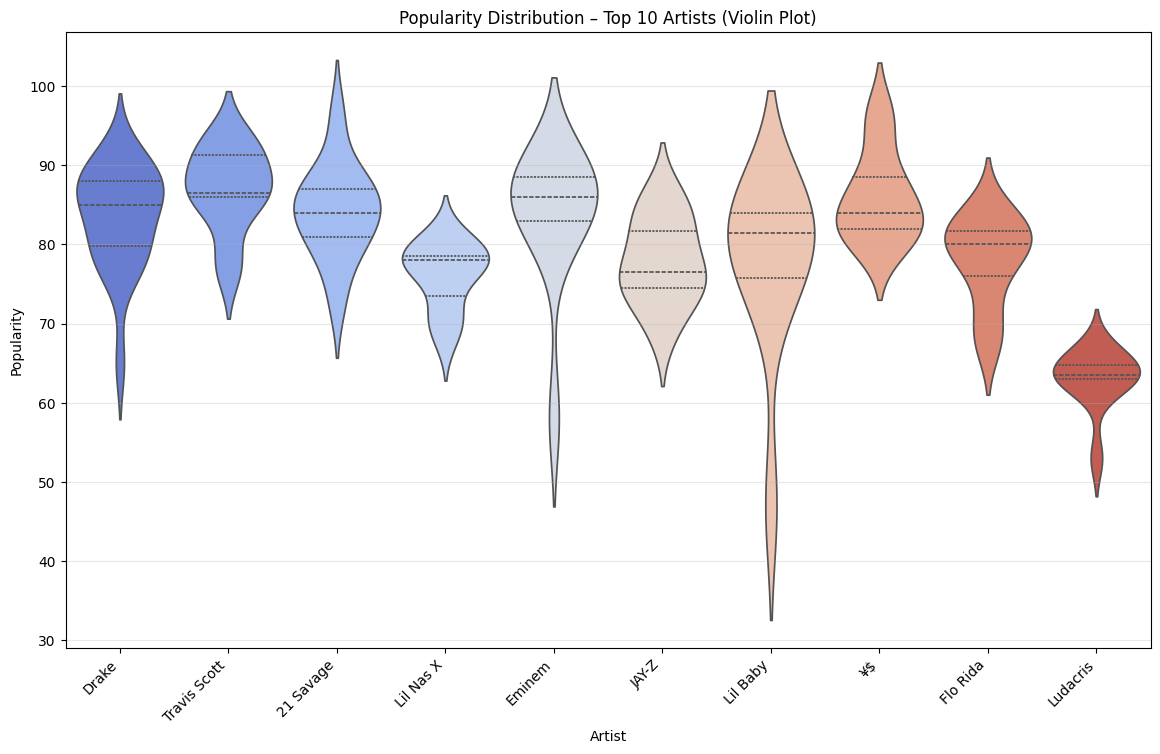

In [175]:
# Q10 How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot
plt.figure(figsize=(14, 8))
sns.violinplot(data=df[df['Artist'].isin(top10_artists)],
               x='Artist', y='Popularity', palette='coolwarm', inner='quartile')
plt.title('Popularity Distribution – Top 10 Artists (Violin Plot)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Popularity')
plt.grid(True, axis='y', alpha=0.3)
plt.show()